In [2]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import logging 
logging.getLogger('pgmpy').setLevel(logging.WARNING)
logging.getLogger('pySOT').setLevel(logging.WARNING)


import warnings 
warnings.filterwarnings("ignore")
from utils.plotting import GraphVisualization
import pandas as pd
from utils.graph import dag_to_cpdag
from metrics.graph import compare_dags

In [3]:
import jointpmf.jointpmf as jp
import jointpmf.central_driver_methods as cdm
import pickle
import copy
import random
import networkx as nx
import numpy as np

In [4]:
# class RenameUnpickler(pickle.Unpickler):
#     def find_class(self, module, name):
#         # Map 'jointpmf.jointpmf' to 'jointpmf'
#         # if module == "jointpmf.jointpmf":
#         #     module = "jointpmf"
#         return super().find_class(module, name)

# with open("jointpmf/precomputed_srvs.pkl", "rb") as f:
#     _precomputed_srvs = RenameUnpickler(f).load()

# read in the precomputed dependent variables with two sources
# with open('jointpmf/precomputed_dependent_vars_two_sources.pkl', 'rb') as f:
#     _precomputed_dependent_vars_two_sources = RenameUnpickler(f).load()

# read in the precomputed dependent variables with one source
# with open('jointpmf/precomputed_dependent_vars_one_source.pkl', 'rb') as f:
#     _precomputed_dependent_vars_one_source = RenameUnpickler(f).load()

In [67]:
# from time import time

# _precomputed_srvs = []

# numvalues = 3
# max_evals_srv = 100
# syn_cutoff = 0.7

# start_time = time()
# for i in tqdm(range(10)):
#     bn = jp.BayesianNetwork()
#     # independent variables to start with (root(s) of the DAG)
#     bn.append_independent_variable('uniform', numvalues)
#     indep_var1 = redund_var = len(bn) - 1
#     indep_var2 = len(bn) - 1
#     bn.append_independent_variable('uniform', numvalues)
#     # add a variable which depends on TWO variables
#     bn.append_synergistic_variable([0, 1], numvalues=numvalues, max_evals=max_evals_srv)
#     print(f'WMS of SRV: {bn.wms([0, 1], [2])} (maximum possible {np.log2(numvalues)})')
#     print(bn.wms([0, 1], [2]) / np.log2(numvalues))
#     if bn.wms([0, 1], [2]) / np.log2(numvalues) > syn_cutoff:
#         cond_pmf_srv = bn.conditional_probabilities([2], [0, 1])
#         _precomputed_srvs.append(cond_pmf_srv)
#         # break
#     else:
#         print(f'\t(SRV was not good enough so it was not appended)')

# end_time = time()
# print(f'Time taken to generate 10 SRV: {end_time - start_time} seconds')

In [1]:
from joblib import Parallel, delayed

numvalues = 3
max_evals_srv = 100
syn_cutoff = 0.5
target_mi = np.log2(numvalues) * 0.1

_precomputed_srvs = []

def generate_srv_candidate(index):
    bn = jp.BayesianNetwork()
    bn.append_independent_variable('uniform', numvalues)
    bn.append_independent_variable('uniform', numvalues)
    bn.append_synergistic_variable([0, 1], numvalues=numvalues, max_evals=max_evals_srv)
    wms_value = bn.wms([0, 1], [2]) / np.log2(numvalues)
    if wms_value > syn_cutoff:
        cond_pmf_srv = bn.conditional_probabilities([2], [0, 1])
        print(f"Generated SRV with WMS: {wms_value}")
        return cond_pmf_srv
    return None

def generate_precomputed_one_source(index):
    bn = jp.BayesianNetwork()
    bn.append_independent_variable('uniform', numvalues)    
    bn.append_dependent_variable([0], numvalues=numvalues, target_mi=target_mi) 
    cond_pmf = bn.conditional_probabilities([1], [0])
    return cond_pmf

results = Parallel(n_jobs=20)(delayed(generate_srv_candidate)(i) for i in range(50))

# Collect non-None results
_precomputed_srvs.extend(filter(None, results))

NameError: name 'np' is not defined

In [ ]:

_precomputed_dependent_vars_one_source = []

def generate_precomputed_one_source(index):
    bn = jp.BayesianNetwork()
    bn.append_independent_variable('uniform', numvalues)    
    bn.append_dependent_variable([0], numvalues=numvalues, target_mi=target_mi) 
    cond_pmf = bn.conditional_probabilities([1], [0])
    return cond_pmf


results = Parallel(n_jobs=20)(delayed(generate_precomputed_one_source)(i) for i in range(10))
_precomputed_dependent_vars_one_source.extend(filter(None, results))


In [ ]:
_precomputed_dependent_vars_two_sources = []

def generate_precomputed_two_source(index):
    bn = jp.BayesianNetwork()
    bn.append_independent_variable('uniform', numvalues)
    bn.append_independent_variable('uniform', numvalues)
    bn.append_dependent_variable([0, 1], numvalues=numvalues, target_mi=target_mi)
    cond_pmf = bn.conditional_probabilities([2], [0, 1])
    return cond_pmf
results = Parallel(n_jobs=20)(delayed(generate_precomputed_two_source)(i) for i in range(10))
_precomputed_dependent_vars_two_sources.extend(filter(None, results))

In [8]:
print(f'Total SRVs generated: {len(_precomputed_srvs)}')
print(f'Total dependent vars with one source generated: {len(_precomputed_dependent_vars_one_source)}')
print(f'Total dependent vars with two sources generated: {len(_precomputed_dependent_vars_two_sources)}')

Total SRVs generated: 44
Total dependent vars with one source generated: 10
Total dependent vars with two sources generated: 10


In [9]:
import numpy as np
import pandas as pd

def mean_abs_pairwise_corr(df: pd.DataFrame, method: str = "pearson") -> float:
    """
    Mean absolute pairwise correlation (MAC) across columns of df.
    Ignores NaNs pairwise and excludes the diagonal.

    Returns NaN if fewer than 2 numeric columns or no valid pairs.
    """
    X = df.select_dtypes(include=[np.number])
    if X.shape[1] < 2:
        return np.nan

    C = X.corr(method=method)              # pairwise correlation matrix
    A = C.to_numpy(dtype=float)

    # upper triangle without diagonal
    iu = np.triu_indices_from(A, k=1)
    vals = np.abs(A[iu])

    # drop NaNs from constant columns / insufficient overlap
    vals = vals[~np.isnan(vals)]
    return float(vals.mean()) if vals.size else np.nan


# usage:
# mac = mean_abs_pairwise_corr(df)
# mac_spearman = mean_abs_pairwise_corr(df, method="spearman")


In [11]:
num_vars = 20
num_roots = 3
pair_probs = 0.7


bn, appended_edges_weight_df =  cdm.construct_jpmf_bn(
        num_vars, num_roots, pair_probs,
        _precomputed_dependent_vars_one_source,
        _precomputed_dependent_vars_two_sources,
        _precomputed_srvs,
        numvalues=3,
    )

In [12]:
samples = bn.generate_samples(10_000)
df_samples = pd.DataFrame(samples)

In [13]:
print(f"Mean absolute pairwise correlation: {mean_abs_pairwise_corr(df_samples)}")

Mean absolute pairwise correlation: 0.05193515067819756


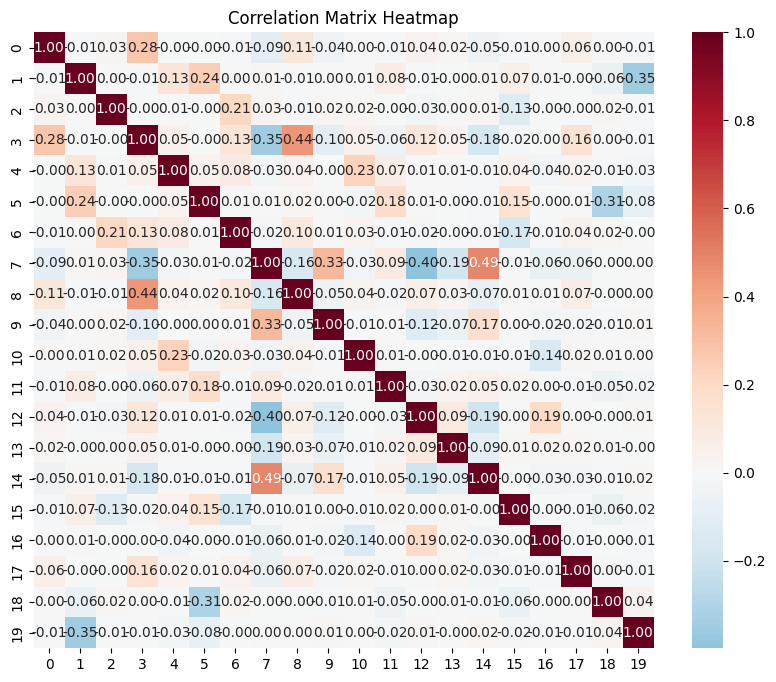

In [14]:
import seaborn as sns

correlation_matrix = df_samples.corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

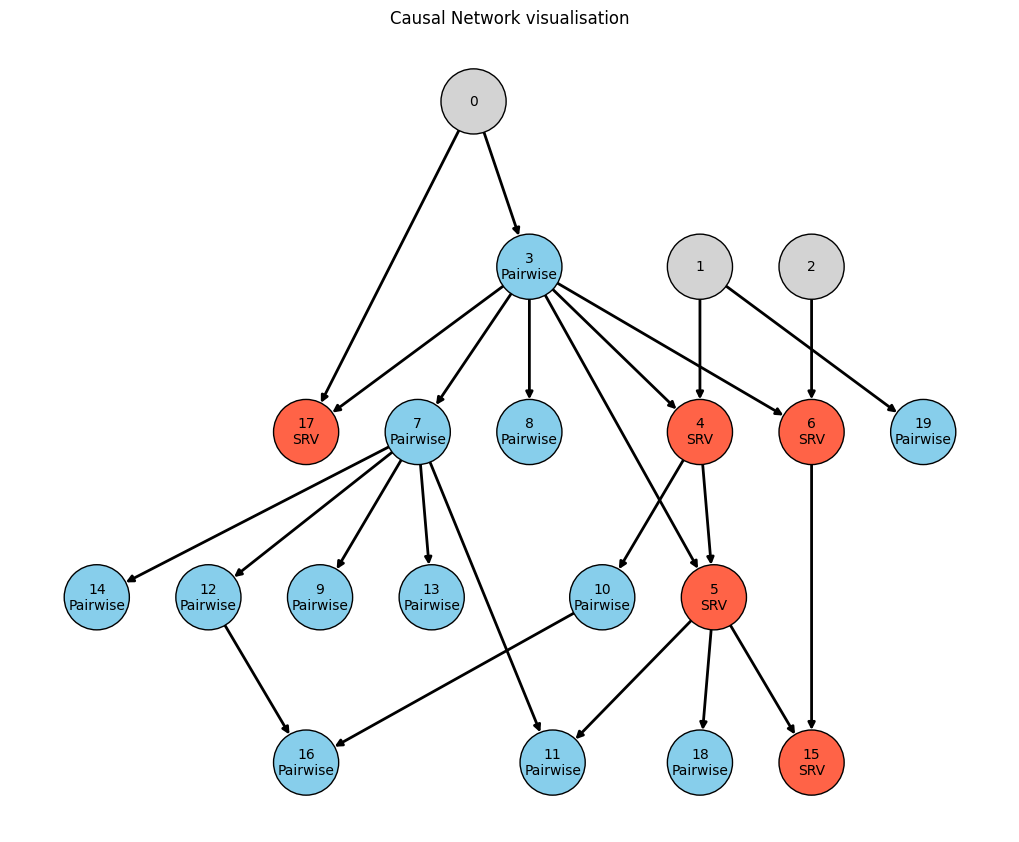

In [15]:
from utils.plotting import visualize_network_labels
from utils.plotting import compare_dags_with_labels

visualize_network_labels(appended_edges_weight_df)

In [59]:
import ast
from networkx.algorithms.dag import colliders

def _as_seq(x):
    """Parse '(1,2,3)' / '[1,2,3]' / (1,2,3) / [1,2,3] into a tuple of ints."""
    if isinstance(x, str):
        x = ast.literal_eval(x)
    if isinstance(x, (list, tuple)):
        return tuple(map(int, x))
    raise TypeError(f"Unsupported collider encoding: {type(x)} -> {x!r}")

def _norm_triplet_from_metadata(t):
    """
    Your metadata seems to store (p1, p2, ..., child) with child last.
    Convert to canonical (min_parent, child, max_parent) for 2-parent colliders.
    """
    parents, child = t[:-1], t[-1]
    if len(parents) != 2:
        return None  # not a simple 2-parent collider triplet
    a, b = sorted(parents)
    return (a, child, b)

def _norm_triplet_from_networkx(t):
    """NetworkX collider is (u, v, w) where v is the collider node."""
    u, v, w = map(int, t)
    a, b = sorted([u, w])
    return (a, v, b)

def evaluate_triplets_one_dataset(metadata_df, learned_dag):
    if "SRV" in metadata_df["Type"].values:
        all_colliders_raw = metadata_df["Combs"]
        synergistic_raw = metadata_df.loc[metadata_df["Type"] == "SRV", "Combs"]
    else:
        all_colliders_raw = metadata_df["Combs"]
        synergistic_raw = metadata_df.loc[metadata_df["Type"] == "XOR", "Combs"]

    # ---- Parse + normalize true (all) colliders ----
    true_all = set()
    for x in all_colliders_raw:
        t = _as_seq(x)
        if len(t) >= 3:
            nt = _norm_triplet_from_metadata(t)
            if nt is not None:
                true_all.add(nt)

    # ---- Normalize learned colliders ----
    learned = set(_norm_triplet_from_networkx(t) for t in colliders(learned_dag))

    correct = true_all & learned
    missing = true_all - learned
    extra = learned - true_all

    tp, fp, fn = len(correct), len(extra), len(missing)
    collider_precision = tp / (tp + fp) if (tp + fp) else 0
    collider_recall    = tp / (tp + fn) if (tp + fn) else 0
    collider_f1        = (2 * collider_precision * collider_recall / (collider_precision + collider_recall)
                          if (collider_precision + collider_recall) else 0)

    # ---- Synergistic colliders (SC) ----
    true_sc = set()
    sc_multi_truth = set()  # (child, frozenset(parents)) for multi-parent cases

    for x in synergistic_raw:
        t = _as_seq(x)
        if len(t) >= 3:
            parents, child = t[:-1], t[-1]
            if len(parents) == 2:
                a, b = sorted(parents)
                true_sc.add((a, child, b))
            if len(parents) >= 3:
                sc_multi_truth.add((int(child), frozenset(map(int, parents))))

    correct_sc = true_sc & learned
    missing_sc = true_sc - learned
    extra_sc   = learned - true_sc  # learned colliders that are not synergistic

    tp_sc, fp_sc, fn_sc = len(correct_sc), len(extra_sc), len(missing_sc)

    sc_precision = tp_sc / (tp_sc + fp_sc) if (tp_sc + fp_sc) else 0
    sc_recall    = tp_sc / (tp_sc + fn_sc) if (tp_sc + fn_sc) else 0
    sc_f1        = (2 * sc_precision * sc_recall / (sc_precision + sc_recall)
                    if (sc_precision + sc_recall) else 0)

    # ---- Multi-parent synergy recall (node-level parent-set match) ----
    learned_parentsets = {(int(v), frozenset(map(int, learned_dag.predecessors(v))))
                          for v in learned_dag.nodes()}
    correct_multi = sc_multi_truth & learned_parentsets
    multi_parent_recall = (len(correct_multi) / len(sc_multi_truth)) if sc_multi_truth else 0

    return {
        "Synergistic Colliders Found": correct_sc,
        "Synergistic Colliders Missing": missing_sc,
        "Colliders Found": correct,
        "Colliders Missing": missing,
        "Precision (Collider)": collider_precision,
        "Recall (Collider)": collider_recall,
        "F1 (Collider)": collider_f1,
        "sc_precision": sc_precision,
        "sc_recall": sc_recall,
        "sc_f1": sc_f1,
        "Recall (Synergy Multi-Parent)": multi_parent_recall,
    }

evaluate_triplets_one_dataset(appended_edges_weight_df, learned_graph_ea)

{'Synergistic Colliders Found': {(0, 17, 3),
  (1, 4, 3),
  (2, 6, 3),
  (3, 5, 4),
  (5, 15, 6)},
 'Synergistic Colliders Missing': set(),
 'Colliders Found': {(0, 17, 3),
  (1, 4, 3),
  (2, 6, 3),
  (3, 5, 4),
  (5, 11, 7),
  (5, 15, 6),
  (10, 16, 12)},
 'Colliders Missing': set(),
 'Precision (Collider)': 0.875,
 'Recall (Collider)': 1.0,
 'F1 (Collider)': 0.9333333333333333,
 'sc_precision': 0.625,
 'sc_recall': 1.0,
 'sc_f1': 0.7692307692307693,
 'Recall (Synergy Multi-Parent)': 0}

In [64]:

# from algorithms.ea import GeneticBNSearch
from metrics.synergy import find_synergistic_triplets
from algorithms.ea_adj import GeneticBNSearchMatrix

def run_ea(df, pop=20, gens=None, score_fn="bic", hill=False, show_progress=True, informed_ratio=0.6, crossover_method='edge_swap'):
    """Run the evolutionary algorithm for structure learning."""
    triplets = find_synergistic_triplets(df)
    # print(len(triplets))
    # print(triplets)
 
    learned_dag, score = GeneticBNSearchMatrix(
            df,
            score_fn=score_fn,
            population_size=pop,
            generations=gens,
            # random_state=42,
            synergy_triplets=triplets,
            informed_ratio=informed_ratio,
            hillclimb_seed=hill,
            show_progress=show_progress,
            crossover_method=crossover_method,
        ).run()
    return learned_dag, score

In [78]:
# from algorithms.benchmark import run_ea
learned_graph_ea, bic_score = run_ea(df_samples, pop=50, gens=None, score_fn="bic", hill=False, show_progress=False, informed_ratio=0.6,       
                                        crossover_method='edge_swap')

In [79]:
compare_dags(true_graph, learned_graph_ea)

{'TP': 20,
 'FP': 5,
 'TN': 351,
 'FN': 4,
 'SHD': 9,
 'Precision': 0.8,
 'Recall': 0.833,
 'F1': 0.816}

In [80]:
evaluate_triplets_one_dataset(appended_edges_weight_df, learned_graph_ea)

{'Synergistic Colliders Found': {(2, 6, 3), (5, 15, 6)},
 'Synergistic Colliders Missing': {(0, 17, 3), (1, 4, 3), (3, 5, 4)},
 'Colliders Found': {(2, 6, 3), (5, 11, 7), (5, 15, 6), (10, 16, 12)},
 'Colliders Missing': {(0, 17, 3), (1, 4, 3), (3, 5, 4)},
 'Precision (Collider)': 0.5714285714285714,
 'Recall (Collider)': 0.5714285714285714,
 'F1 (Collider)': 0.5714285714285714,
 'sc_precision': 0.2857142857142857,
 'sc_recall': 0.4,
 'sc_f1': 0.3333333333333333,
 'Recall (Synergy Multi-Parent)': 0}

In [81]:
from algorithms.benchmark import run_hc
from metrics.graph import compare_dags
from utils.graph import create_graph

In [82]:
learned_graph, bic_score = run_hc(df_samples)
true_graph = create_graph(appended_edges_weight_df)

True Graph
[(np.int64(0), 3), (np.int64(0), 17), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 17), (np.int64(1), 4), (np.int64(1), 19), (4, 5), (4, 10), (5, 11), (5, 15), (5, 18), (np.int64(2), 6), (6, 15), (7, 9), (7, 11), (7, 12), (7, 13), (7, 14), (10, 16), (12, 16)]
Learned Graph
[(np.int64(1), np.int64(19)), (np.int64(2), np.int64(3)), (np.int64(2), np.int64(15)), (np.int64(3), np.int64(1)), (np.int64(3), np.int64(5)), (np.int64(3), np.int64(8)), (np.int64(3), np.int64(0)), (np.int64(3), np.int64(7)), (np.int64(3), np.int64(4)), (np.int64(3), np.int64(17)), (np.int64(15), np.int64(4)), (np.int64(15), np.int64(5)), (np.int64(5), np.int64(18)), (np.int64(5), np.int64(11)), (np.int64(7), np.int64(14)), (np.int64(7), np.int64(12)), (np.int64(7), np.int64(9)), (np.int64(7), np.int64(11)), (np.int64(7), np.int64(13)), (np.int64(4), np.int64(1)), (np.int64(4), np.int64(5)), (np.int64(4), np.int64(10)), (np.int64(17), np.int64(0)), (np.int64(10), np.int64(16)), (np.int64(6), np.int64(3)), 

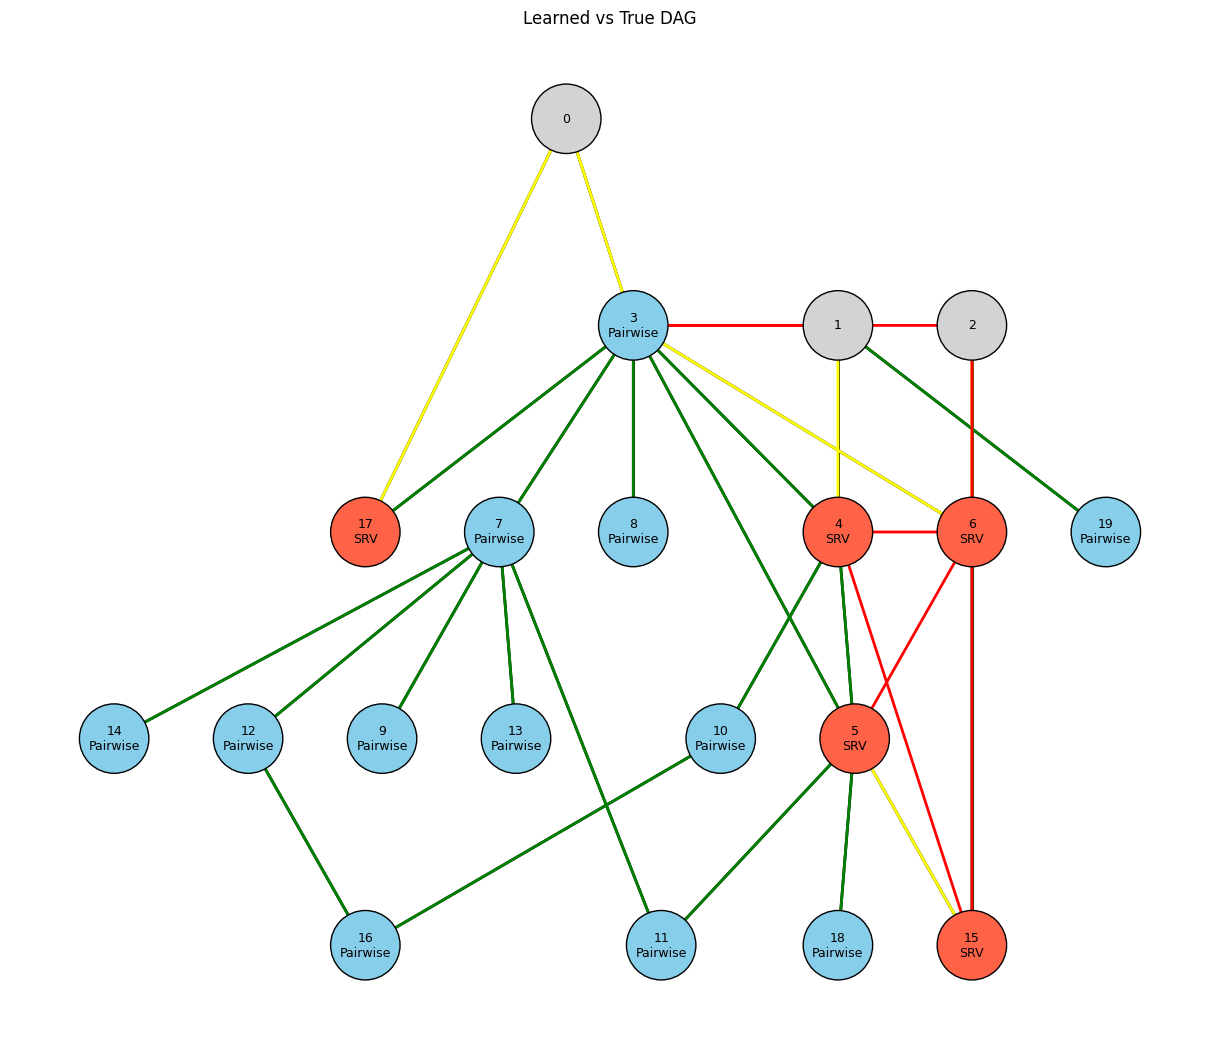

{'correct': {(1, 19),
  (3, 4),
  (3, 5),
  (3, 7),
  (3, 8),
  (3, 17),
  (4, 5),
  (4, 10),
  (5, 11),
  (5, 18),
  (6, 15),
  (7, 9),
  (7, 11),
  (7, 12),
  (7, 13),
  (7, 14),
  (10, 16),
  (12, 16)},
 'wrong_dir': {(3, 0), (4, 1), (6, 2), (6, 3), (15, 5), (17, 0)},
 'extra': {(2, 3), (2, 15), (3, 1), (6, 4), (6, 5), (15, 4)},
 'missing': {(0, 3), (0, 17), (1, 4), (2, 6), (3, 6), (5, 15)},
 'precision': 0.6,
 'recall': 0.75,
 'f1': 0.6666666666666665}

In [85]:
# compare_dags_with_labels(true_graph, dag_to_cpdag(learned_graph_ea), metadata=appended_edges_weight_df)

compare_dags_with_labels(true_graph, learned_graph, metadata=appended_edges_weight_df)

In [25]:
compare_dags(true_graph, learned_graph)

{'TP': 18,
 'FP': 12,
 'TN': 344,
 'FN': 6,
 'SHD': 18,
 'Precision': 0.6,
 'Recall': 0.75,
 'F1': 0.667}

True Graph
[(np.int64(0), 3), (np.int64(0), 17), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 17), (np.int64(1), 4), (np.int64(1), 19), (4, 5), (4, 10), (5, 11), (5, 15), (5, 18), (np.int64(2), 6), (6, 15), (7, 9), (7, 11), (7, 12), (7, 13), (7, 14), (10, 16), (12, 16)]
Learned Graph
[(np.int64(1), np.int64(19)), (np.int64(2), np.int64(3)), (np.int64(2), np.int64(15)), (np.int64(3), np.int64(1)), (np.int64(3), np.int64(5)), (np.int64(3), np.int64(8)), (np.int64(3), np.int64(0)), (np.int64(3), np.int64(7)), (np.int64(3), np.int64(4)), (np.int64(3), np.int64(17)), (np.int64(15), np.int64(4)), (np.int64(15), np.int64(5)), (np.int64(5), np.int64(18)), (np.int64(5), np.int64(11)), (np.int64(7), np.int64(14)), (np.int64(7), np.int64(12)), (np.int64(7), np.int64(9)), (np.int64(7), np.int64(11)), (np.int64(7), np.int64(13)), (np.int64(4), np.int64(1)), (np.int64(4), np.int64(5)), (np.int64(4), np.int64(10)), (np.int64(17), np.int64(0)), (np.int64(10), np.int64(16)), (np.int64(6), np.int64(3)), 

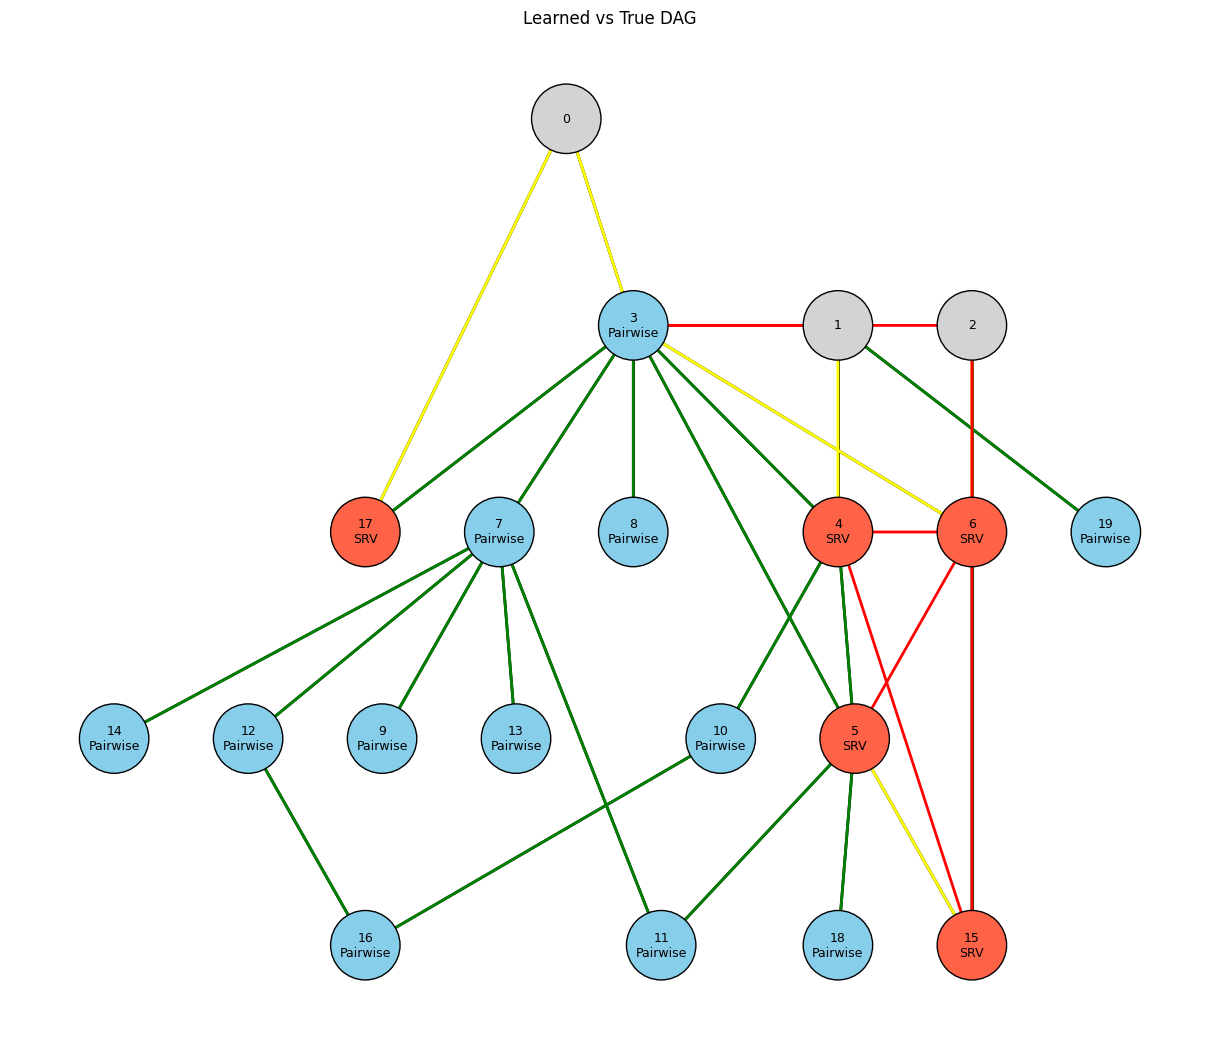

{'correct': {(1, 19),
  (3, 4),
  (3, 5),
  (3, 7),
  (3, 8),
  (3, 17),
  (4, 5),
  (4, 10),
  (5, 11),
  (5, 18),
  (6, 15),
  (7, 9),
  (7, 11),
  (7, 12),
  (7, 13),
  (7, 14),
  (10, 16),
  (12, 16)},
 'wrong_dir': {(3, 0), (4, 1), (6, 2), (6, 3), (15, 5), (17, 0)},
 'extra': {(2, 3), (2, 15), (3, 1), (6, 4), (6, 5), (15, 4)},
 'missing': {(0, 3), (0, 17), (1, 4), (2, 6), (3, 6), (5, 15)},
 'precision': 0.6,
 'recall': 0.75,
 'f1': 0.6666666666666665}

In [76]:
compare_dags_with_labels(true_graph, learned_graph, metadata=appended_edges_weight_df)

True Graph
[(np.int64(0), 3), (np.int64(0), 17), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 17), (np.int64(1), 4), (np.int64(1), 19), (4, 5), (4, 10), (5, 11), (5, 15), (5, 18), (np.int64(2), 6), (6, 15), (7, 9), (7, 11), (7, 12), (7, 13), (7, 14), (10, 16), (12, 16)]
Learned Graph
[(0, 17), (1, 4), (2, 6), (3, 0), (3, 4), (3, 5), (3, 6), (3, 17), (3, 19), (4, 5), (4, 8), (4, 10), (4, 16), (4, 19), (5, 8), (5, 15), (5, 18), (6, 15), (7, 3), (7, 9), (7, 14), (12, 7), (12, 11), (12, 16), (13, 7), (13, 12)]

✅ Correct edges: [(0, 17), (1, 4), (2, 6), (3, 4), (3, 5), (3, 6), (3, 17), (4, 5), (4, 10), (5, 15), (5, 18), (6, 15), (7, 9), (7, 14), (12, 16)]
🔄 Wrong-direction edges: [(3, 0), (7, 3), (12, 7), (13, 7)]
⚠️ Extra edges: [(3, 19), (4, 8), (4, 16), (4, 19), (5, 8), (12, 11), (13, 12)]
❌ Missing edges: [(0, 3), (1, 19), (3, 7), (3, 8), (5, 11), (7, 11), (7, 12), (7, 13), (10, 16)]

📊 Precision: 0.58, Recall: 0.62, F1: 0.60


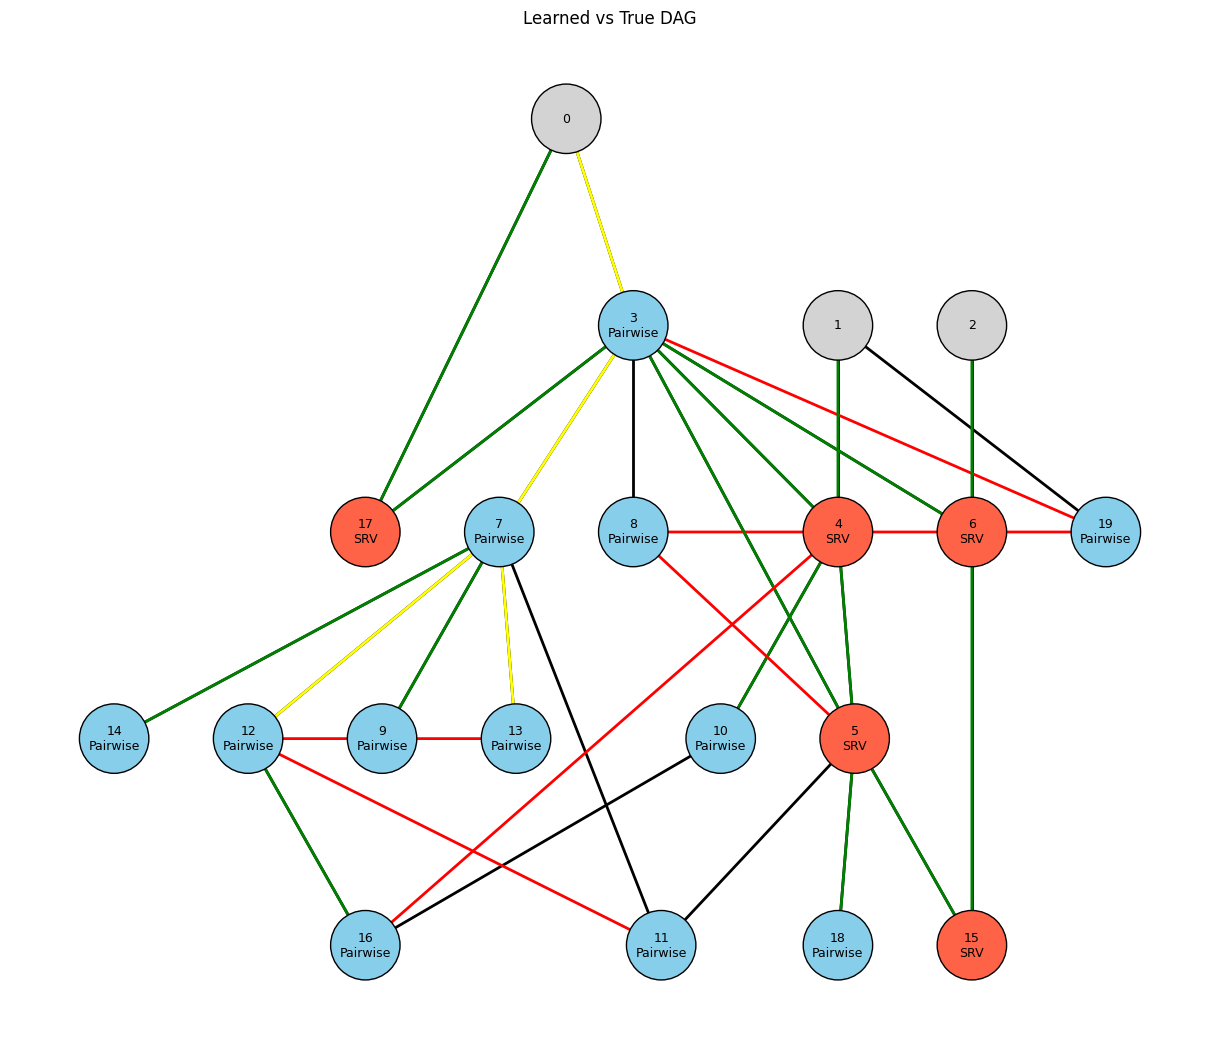

{'correct': {(0, 17),
  (1, 4),
  (2, 6),
  (3, 4),
  (3, 5),
  (3, 6),
  (3, 17),
  (4, 5),
  (4, 10),
  (5, 15),
  (5, 18),
  (6, 15),
  (7, 9),
  (7, 14),
  (12, 16)},
 'wrong_dir': {(3, 0), (7, 3), (12, 7), (13, 7)},
 'extra': {(3, 19), (4, 8), (4, 16), (4, 19), (5, 8), (12, 11), (13, 12)},
 'missing': {(0, 3),
  (1, 19),
  (3, 7),
  (3, 8),
  (5, 11),
  (7, 11),
  (7, 12),
  (7, 13),
  (10, 16)},
 'precision': 0.5769230769230769,
 'recall': 0.625,
 'f1': 0.6}

In [77]:
compare_dags_with_labels(true_graph, learned_graph_ea, appended_edges_weight_df)